In [60]:
!pip install matplotlib



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

ping_file   = "../../experiments/03_longitudinal_routing/results/run_20260612_48h/normalized/fact_ping.csv"
sites_file  = "../../experiments/03_longitudinal_routing/results/run_20260612_48h/normalized/dim_site.csv"
probes_file = "../../experiments/03_longitudinal_routing/results/run_20260612_48h/normalized/dim_probe.csv"



In [62]:
sites = pd.read_csv(sites_file)
probes = pd.read_csv(probes_file)
pings = pd.read_csv(ping_file)

pings.sample(20)

,ping_id,ping_time,probe_id,site_id,probe_asn_measured,sent,rcvd,loss_pct,rtt_min,rtt_avg,rtt_max,measurement_id
2268,2269,2026-06-14T16:46:47+00:00,1016126,10,17557,3,3,0.0,277.033305,277.543499,278.241178,180055876
19119,19120,2026-06-15T10:21:11+00:00,7764,3,17557,3,0,100.0,NaN,NaN,NaN,180055857
22565,22566,2026-06-15T14:07:47+00:00,62224,7,38193,3,3,0.0,224.409677,224.776753,225.047819,180055883
3794,3795,2026-06-14T18:22:12+00:00,1016143,2,9541,3,3,0.0,4.992198,5.104247,5.276210,180055866
37034,37035,2026-06-16T07:26:28+00:00,62224,9,38193,3,3,0.0,180.808286,181.330284,182.056729,180055901
4130,4131,2026-06-14T18:42:38+00:00,1016036,9,9541,3,3,0.0,176.635131,176.747127,176.869141,180055901
40088,40089,2026-06-16T11:06:39+00:00,60223,3,23674,3,0,100.0,NaN,NaN,NaN,180055857
4355,4356,2026-06-14T18:57:14+00:00,7613,7,152605,3,3,0.0,219.005952,219.534629,220.084560,180055883
17049,17050,2026-06-15T08:11:22+00:00,60223,4,23674,3,3,0.0,3.444961,3.646234,3.981332,180055874
19072,19073,2026-06-15T10:17:18+00:00,62224,2,38193,3,3,0.0,22.302601,23.401270,23.982447,180055866


In [63]:
probe_names = dict(zip(probes['probe_id'], probes['isp'] + '.' + probes['city_code']))
pings['probe_name'] = pings['probe_id'].map(probe_names)
pings_filtered = pings[pings['loss_pct'] != 100.0]
pings_filtered.sample(20)

,ping_id,ping_time,probe_id,site_id,probe_asn_measured,sent,rcvd,loss_pct,rtt_min,rtt_avg,rtt_max,measurement_id,probe_name
27118,27119,2026-06-15T19:36:09+00:00,1015679,6,136174,3,3,0.0,21.420459,21.822310,22.562921,180055869,nova.lhe
31806,31807,2026-06-16T01:12:15+00:00,1016036,10,9541,3,3,0.0,24.718957,24.877741,25.013070,180055876,cybernet.hrp
40395,40396,2026-06-16T11:27:41+00:00,1016126,1,17557,3,3,0.0,116.867640,117.158736,117.376238,180055880,ptcl.khi
13857,13858,2026-06-15T04:51:29+00:00,62224,9,38193,3,3,0.0,181.305592,183.084510,184.522862,180055901,transworld.lhe
33880,33881,2026-06-16T03:41:11+00:00,1016126,6,17557,3,3,0.0,26.207498,26.600782,26.875368,180055869,ptcl.khi
20944,20945,2026-06-15T12:15:39+00:00,7613,10,152605,3,3,0.0,94.746077,95.626912,96.927822,180055876,zcom.lhe
7060,7061,2026-06-14T21:46:38+00:00,62224,9,38193,3,3,0.0,184.099313,184.925844,186.338243,180055901,transworld.lhe
22124,22125,2026-06-15T13:37:04+00:00,1016126,4,17557,3,3,0.0,286.741248,287.091268,287.338181,180055874,ptcl.khi
14748,14749,2026-06-15T05:46:51+00:00,1016143,4,9541,3,3,0.0,5.113657,5.289300,5.563346,180055874,cybernet.khi
8106,8107,2026-06-14T22:51:45+00:00,1016126,7,17557,3,3,0.0,211.515490,211.822177,212.166069,180055883,ptcl.khi


In [64]:
ping_by_probe = pings_filtered.groupby('probe_id')
ping_by_probe.sample(10)

,ping_id,ping_time,probe_id,site_id,probe_asn_measured,sent,rcvd,loss_pct,rtt_min,rtt_avg,rtt_max,measurement_id,probe_name
23356,23357,2026-06-15T15:06:07+00:00,7613,9,152605,3,3,0.0,168.756296,168.931000,169.215941,180055901,zcom.lhe
16065,16066,2026-06-15T07:10:35+00:00,7613,10,152605,3,3,0.0,94.573199,95.145199,96.200710,180055876,zcom.lhe
36522,36523,2026-06-16T06:50:42+00:00,7613,1,152605,3,3,0.0,94.829103,94.866969,94.897382,180055880,zcom.lhe
7094,7095,2026-06-14T21:47:37+00:00,7613,6,152605,3,3,0.0,19.433736,19.476746,19.533393,180055869,zcom.lhe
6457,6458,2026-06-14T21:07:43+00:00,7613,6,152605,3,3,0.0,19.467119,19.501519,19.561043,180055869,zcom.lhe
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6389,6390,2026-06-14T21:05:34+00:00,1016143,7,9541,3,3,0.0,203.497132,203.811820,204.053695,180055883,cybernet.khi
11003,11004,2026-06-15T01:52:27+00:00,1016143,10,9541,3,3,0.0,4.985592,5.219239,5.479552,180055876,cybernet.khi
5909,5910,2026-06-14T20:35:40+00:00,1016143,7,9541,3,3,0.0,203.488639,203.763883,204.016401,180055883,cybernet.khi
8680,8681,2026-06-14T23:27:19+00:00,1016143,10,9541,3,3,0.0,4.905272,5.025897,5.153658,180055876,cybernet.khi


In [65]:
ping_by_probe_by_site = pings_filtered.groupby(['probe_id','site_id'])

In [66]:
g1 = ping_by_probe_by_site.get_group((7613, 1))
g1

,ping_id,ping_time,probe_id,site_id,probe_asn_measured,sent,rcvd,loss_pct,rtt_min,rtt_avg,rtt_max,measurement_id,probe_name
12,13,2026-06-14T14:25:45+00:00,7613,1,152605,3,3,0.0,95.338634,95.528062,95.842724,180055880,zcom.lhe
93,94,2026-06-14T14:30:45+00:00,7613,1,152605,3,3,0.0,95.284741,95.383026,95.548734,180055880,zcom.lhe
242,243,2026-06-14T14:40:44+00:00,7613,1,152605,2,2,0.0,95.378032,95.378991,95.379950,180055880,zcom.lhe
326,327,2026-06-14T14:45:52+00:00,7613,1,152605,3,3,0.0,95.190441,95.344684,95.516339,180055880,zcom.lhe
403,404,2026-06-14T14:50:43+00:00,7613,1,152605,3,3,0.0,97.457770,97.600017,97.800429,180055880,zcom.lhe
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42434,42435,2026-06-16T13:55:51+00:00,7613,1,152605,3,3,0.0,94.614836,94.697675,94.791767,180055880,zcom.lhe
42488,42489,2026-06-16T14:00:38+00:00,7613,1,152605,2,1,50.0,95.354193,95.354193,95.354193,180055880,zcom.lhe
42626,42627,2026-06-16T14:10:48+00:00,7613,1,152605,3,2,33.3,94.581319,94.626575,94.671831,180055880,zcom.lhe
42695,42696,2026-06-16T14:15:42+00:00,7613,1,152605,2,2,0.0,94.679065,94.855715,95.032365,180055880,zcom.lhe


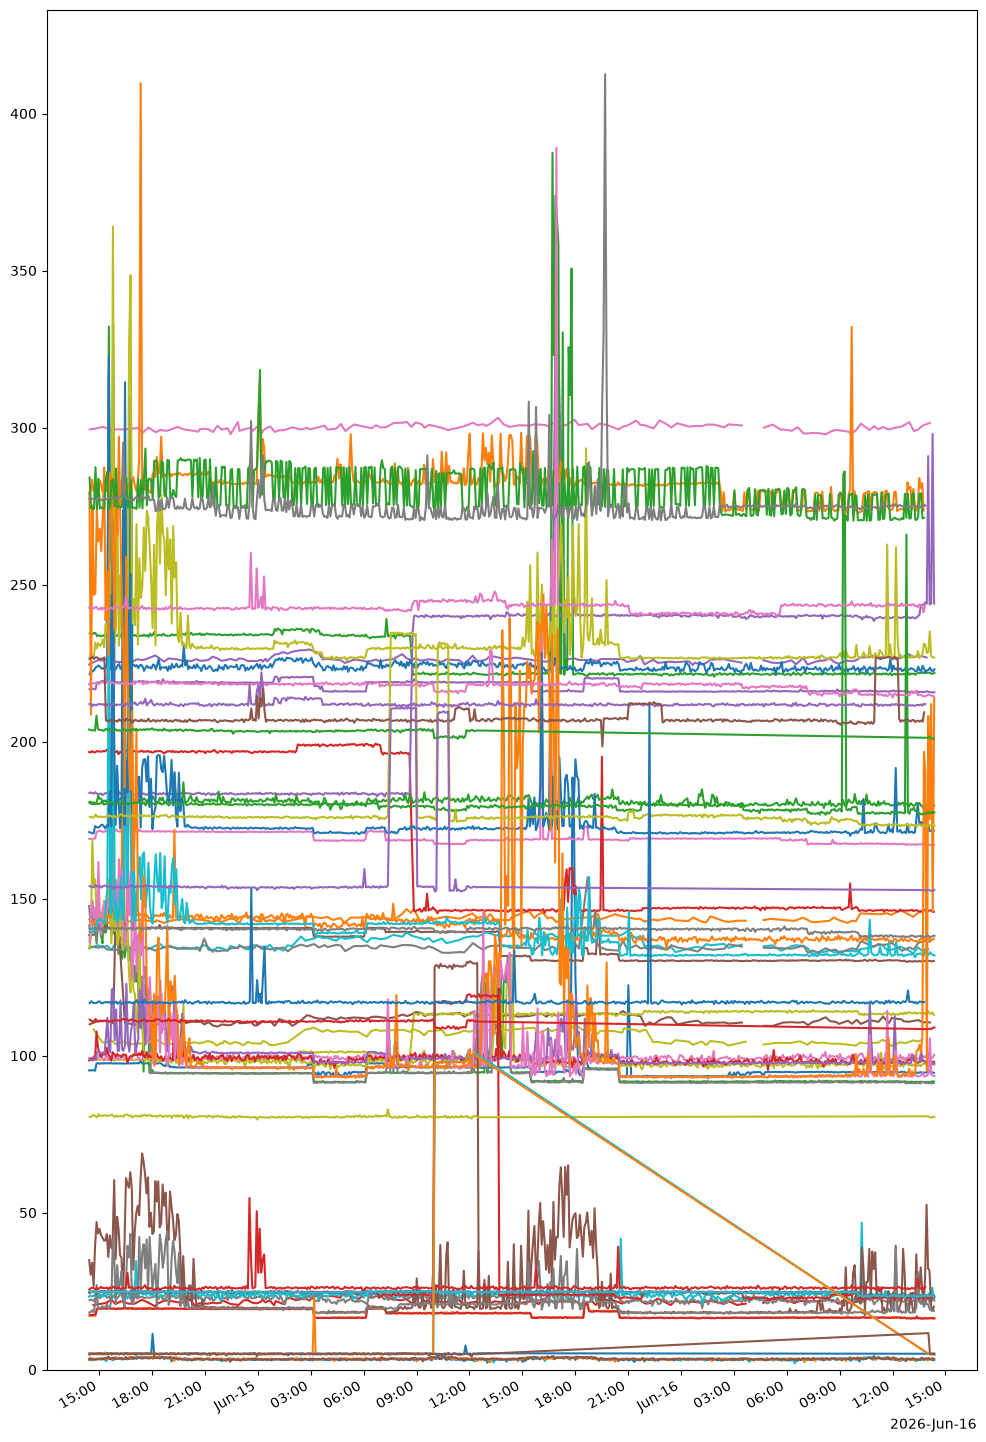

In [67]:
fig, ax = plt.subplots(figsize=(12, 20))

for (probe, site), group in ping_by_probe_by_site:
    x = pd.to_datetime(group['ping_time'])
    y = group['rtt_min']
    ax.plot(x, y)

ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.ylim(bottom=0) 
fig.autofmt_xdate()

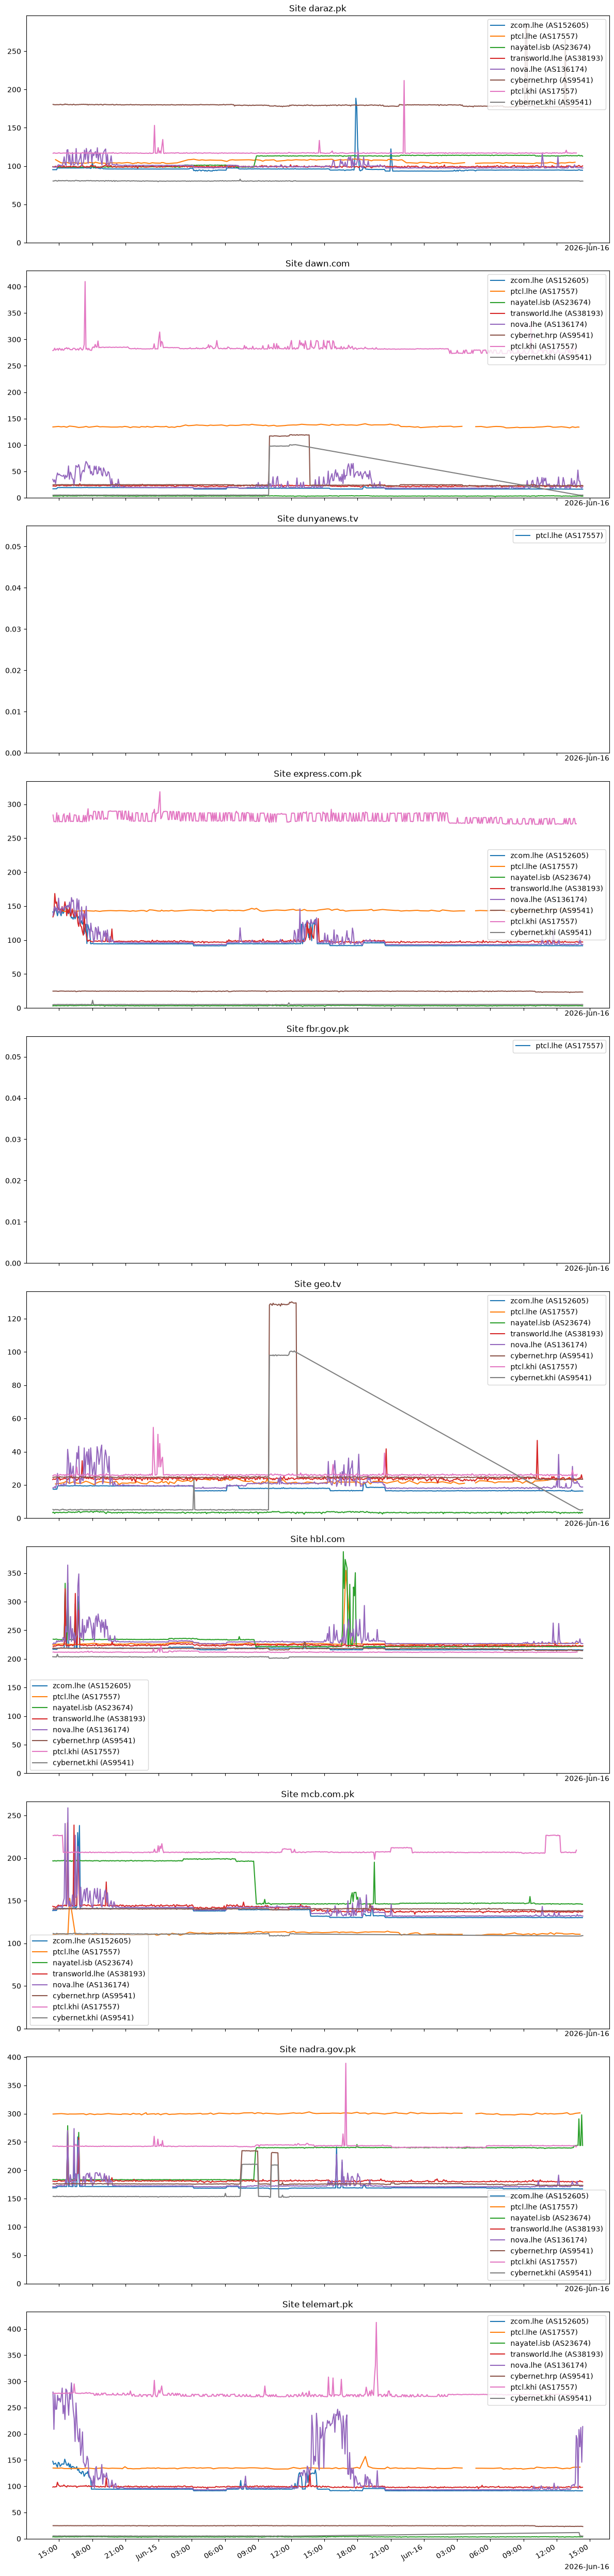

In [68]:
n_sites = sites.shape[0]

fig, axes = plt.subplots(n_sites, 1, figsize=(12, 5 * n_sites), sharex = True)

if n_sites == 1:
    axes = [axes]
    
for ax, site in zip(axes, sites['site_id']):
    site_data = pings_filtered[pings_filtered['site_id'] == site]
    site_name = sites[sites["site_id"] == site]["target_hostname"].values[0]
    
    for probe, group in site_data.groupby('probe_id'):
        probe_name = probes[probes['probe_id'] == probe]['label'].values[0]
        x = pd.to_datetime(group['ping_time'])
        y = group['rtt_min']
        ax.plot(x, y, label=f'{probe_name}')
    
    ax.set_title(f'Site {site_name}')
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=20))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.tick_params(labelbottom=True)
    ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [69]:
sites[sites['site_id'] == 1]['target_hostname'].values[0]

'daraz.pk'

In [70]:
sites

,site_id,target_label,target_hostname,target_category
0,1,Daraz,daraz.pk,ecommerce
1,2,Dawn,dawn.com,news
2,3,Dunya News,dunyanews.tv,news
3,4,Express,express.com.pk,news
4,5,FBR,fbr.gov.pk,government
5,6,Geo TV,geo.tv,news
6,7,HBL Bank,hbl.com,banking
7,8,MCB Bank,mcb.com.pk,banking
8,9,NADRA,nadra.gov.pk,government
9,10,Telemart,telemart.pk,ecommerce


## TODO: Check out 
Site ID 10 for probe ID 1015679, June 14 3 pm to 6 pm, then 6 pm to June 15 12 pm. June 15 2 pm to 6 pm.

Site ID 9 from probe ID 1016143 on June 15 9 am to 10 am

Site ID 8 from probe ID 60223 on June 14 till June 15 9 am

Site ID 6 from probe IDs 1016036 and 1016143 on June 15 from 10 am to 1 pm

Site ID 3 from probe IDs 1016036 and 1016143 on June 15 from 10 am to 1 pm

Site ID 1 June 15 9 am onwards for probe ID 60223


In [71]:
import re
def pat_dest(test):
    pattern = r'([\w.-]+\.[a-z.]+)\s+-\s+([\w\s]+?)\s+\(([\w\s]+)\)'
    match = re.search(pattern, test)
    if match:
        url, name, category = match.groups()
    else:
        print(f'{test} not matched')
    return (url, name, category)

def pat_time(test):
    pattern = r'\w+\s+(\d{4})-(\d{2})-(\d{1,2})t(\d{2}:\d{1,2}:\d{2})(\+\d{2}:\d{2})'
    match = re.search(pattern, test)
    if match:
        (year, month, day, time, tz) = match.groups()
    else:
        print(f'{test} not matched')
    return (year, month, day, time, tz)
    
def read_trace(f, trace_id, sites, probes):
    # The next line contains the site URL, name and category    
    next = f.readline()
    (site_url, site, category) = pat_dest(next.strip().lower())
    site_id = sites.index[sites['target_hostname'] == site_url]
    # tokens = next.split('-')
    # site_url = tokens[0].strip()
    # tokens = tokens[1].split()
    # site = tokens[0].strip()
    # category = tokens[1].strip()
    
    # The next line contains time
    next = f.readline()
    (year, month, day, time, tz) = pat_time(next.strip().lower())
    # tokens = next.split()
    # time = tokens[1]
    # tokens = tokens[1].split('T')
    # date = tokens[0]
    # time_str = tokens[1]
    
    # The next line contains source probe information
    next = f.readline()
    tokens = next.split('-')
    probe_id = tokens[0].split()[2]
    probe_asn = tokens[1].strip()
    probe_name = tokens[2].strip()
    src = probe_id
    # src = " ".join(tokens[6:])
    
    # The next line contains the destination information
    next = f.readline()
    tokens = next.split()
    dest = " ".join(tokens[1:])
    # The next line is blank
    f.readline()
    # The next line has a long --- string
    f.readline()

    tf = pd.DataFrame({'trace_id': trace_id, 'site_id': site_id,  
                       'year': year, 'month': month, 'day': day, 'time': time, 'timezone': tz, 
                      'probe_id': probe_id, 'dest': dest}, index=[0])
    # The next lines contain the traceroute hop by hop
    next = f.readline()
    # hop_numbers = []
    # hop_ips = []
    # hop_rtt = []
    hop_records = []
    while len(next) > 1:
        tokens = next.split()
        row = {
            'trace_id': trace_id,
            'hop_number': tokens[0],
            'hop_rtt': tokens[1],
            'hop_ip': tokens[2]
        }
        hop_records.append(row)
        # hop_numbers.append(tokens[0])
        # hop_rtt.append(tokens[1])
        # hop_ips.append(tokens[2])
        
        next = f.readline()
    df = pd.DataFrame(hop_records)
    # return (site, time, src, dest, hop_numbers, hop_ips, hop_rtt)
    return tf, df
    
def load_data_file(file_path, sites, probes):
    data = []
    trace_id = 0
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            master_hops = []
            master_trace_ids = []
            # The first line contains the header. Skip it
            f.readline()
            # The second line contains the number of traces. Save it somewhere
            next = f.readline()
            tokens = next.split()
            count = tokens[0]
            # The next line is blank
            f.readline()
            # The next line has a long ==== string
            f.readline()
            done = False
            while not done:
                tf, df = read_trace(f, trace_id, sites, probes)
                master_hops.append(df)
                master_trace_ids.append(tf)
                # data.append(tup)
                trace_id += 1
                if not f.readline():
                    done = True
            # 1. Use pd.concat for the list of hop dataframes
            df_hops = pd.concat(master_hops, ignore_index=True) if master_hops else pd.DataFrame()
            
            # 2. Use pd.concat for the trace metadata dataframes too (since they are now 2D with index=[0])
            df_traces = pd.concat(master_trace_ids, ignore_index=True) if master_trace_ids else pd.DataFrame()
                
    except Exception as e:
        print(f"Error reading file in background thread: {e}")
    df_traces = df_traces.set_index('trace_id', drop=True)
    return df_traces, df_hops

file_path = '../../experiments/03_longitudinal_routing/results/run_20260612_48h/routes_20260616_142719.txt'
df_traces, df_hops = load_data_file(file_path, sites, probes)

In [72]:
df_traces.head()

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
0,0,2026,06,14,14:25:39,+00:00,7764,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
1,0,2026,06,14,14:26:03,+00:00,1016036,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
2,0,2026,06,14,14:26:09,+00:00,1016143,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
3,0,2026,06,14,14:28:29,+00:00,1015679,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...
4,0,2026,06,14,14:28:35,+00:00,1016126,47.246.167.168 - ALIBABA-CN-NET - Alibaba (US)...


In [73]:
set_1 = df_traces[df_traces['site_id'] == 9] 
# set_1 = set_1[set_1['probe_id'] == 1015679]

In [74]:
set_1[set_1['probe_id'] == '1015679']

,site_id,year,month,day,time,timezone,probe_id,dest
trace_id,,,,,,,,
12894,9,2026,06,14,14:31:28,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
12901,9,2026,06,14,14:46:29,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
12909,9,2026,06,14,15:01:19,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
12918,9,2026,06,14,15:16:27,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
12925,9,2026,06,14,15:31:23,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
...,...,...,...,...,...,...,...,...
14289,9,2026,06,16,13:16:30,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14297,9,2026,06,16,13:31:31,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."
14303,9,2026,06,16,13:46:32,+00:00,1015679,"172.67.195.207 - CLOUDFLARENET - Cloudflare, I..."


In [79]:
probe_label_map = dict(zip(probes.index, probes['isp'] + '.' + probes['city_code']))
# find probe-site pairs with highest RTT variance — candidates for anomalies
variance = (
    pings_filtered
    .groupby(['probe_id', 'site_id'])['rtt_avg']
    .std()
    .reset_index()
    .sort_values('rtt_avg', ascending=False)
)
variance['probe_name'] = variance['probe_id'].astype(int).map(probe_label_map)
exclude_sites = ['fbr.gov.pk', 'dunyanews.tv']
variance = variance.merge(sites[['target_hostname']], left_on='site_id', right_index=True)
variance = variance[~variance['target_hostname'].isin(exclude_sites)]
print(variance.head(20).to_string())

    probe_id  site_id    rtt_avg probe_name target_hostname
39   1015679        8  79.839104        NaN    nadra.gov.pk
34   1015679        1  77.079144        NaN        dawn.com
40   1015679        9  46.913453        NaN     telemart.pk
37   1015679        6  46.272280        NaN         hbl.com
38   1015679        7  33.525196        NaN      mcb.com.pk
61   1016143        6  29.475290        NaN         hbl.com
24     60223        9  28.047365        NaN     telemart.pk
23     60223        8  24.585725        NaN    nadra.gov.pk
45   1016036        6  23.220720        NaN         hbl.com
22     60223        7  17.735519        NaN      mcb.com.pk
53   1016126        6  17.619478        NaN         hbl.com
64   1016143        9  16.753834        NaN     telemart.pk
14      7764        7  12.328632        NaN      mcb.com.pk
48   1016036        9  12.061987        NaN     telemart.pk
56   1016126        9   9.064250        NaN     telemart.pk
5       7613        8   8.518402        

In [78]:
print(type(list(probe_label_map.keys())[0]))
print(type(variance['probe_id'].iloc[0]))
print(probe_label_map)

<class 'int'>
<class 'numpy.int64'>
{0: 'zcom.lhe', 1: 'ptcl.lhe', 2: 'nayatel.isb', 3: 'transworld.lhe', 4: 'nova.lhe', 5: 'cybernet.hrp', 6: 'ptcl.khi', 7: 'cybernet.khi'}


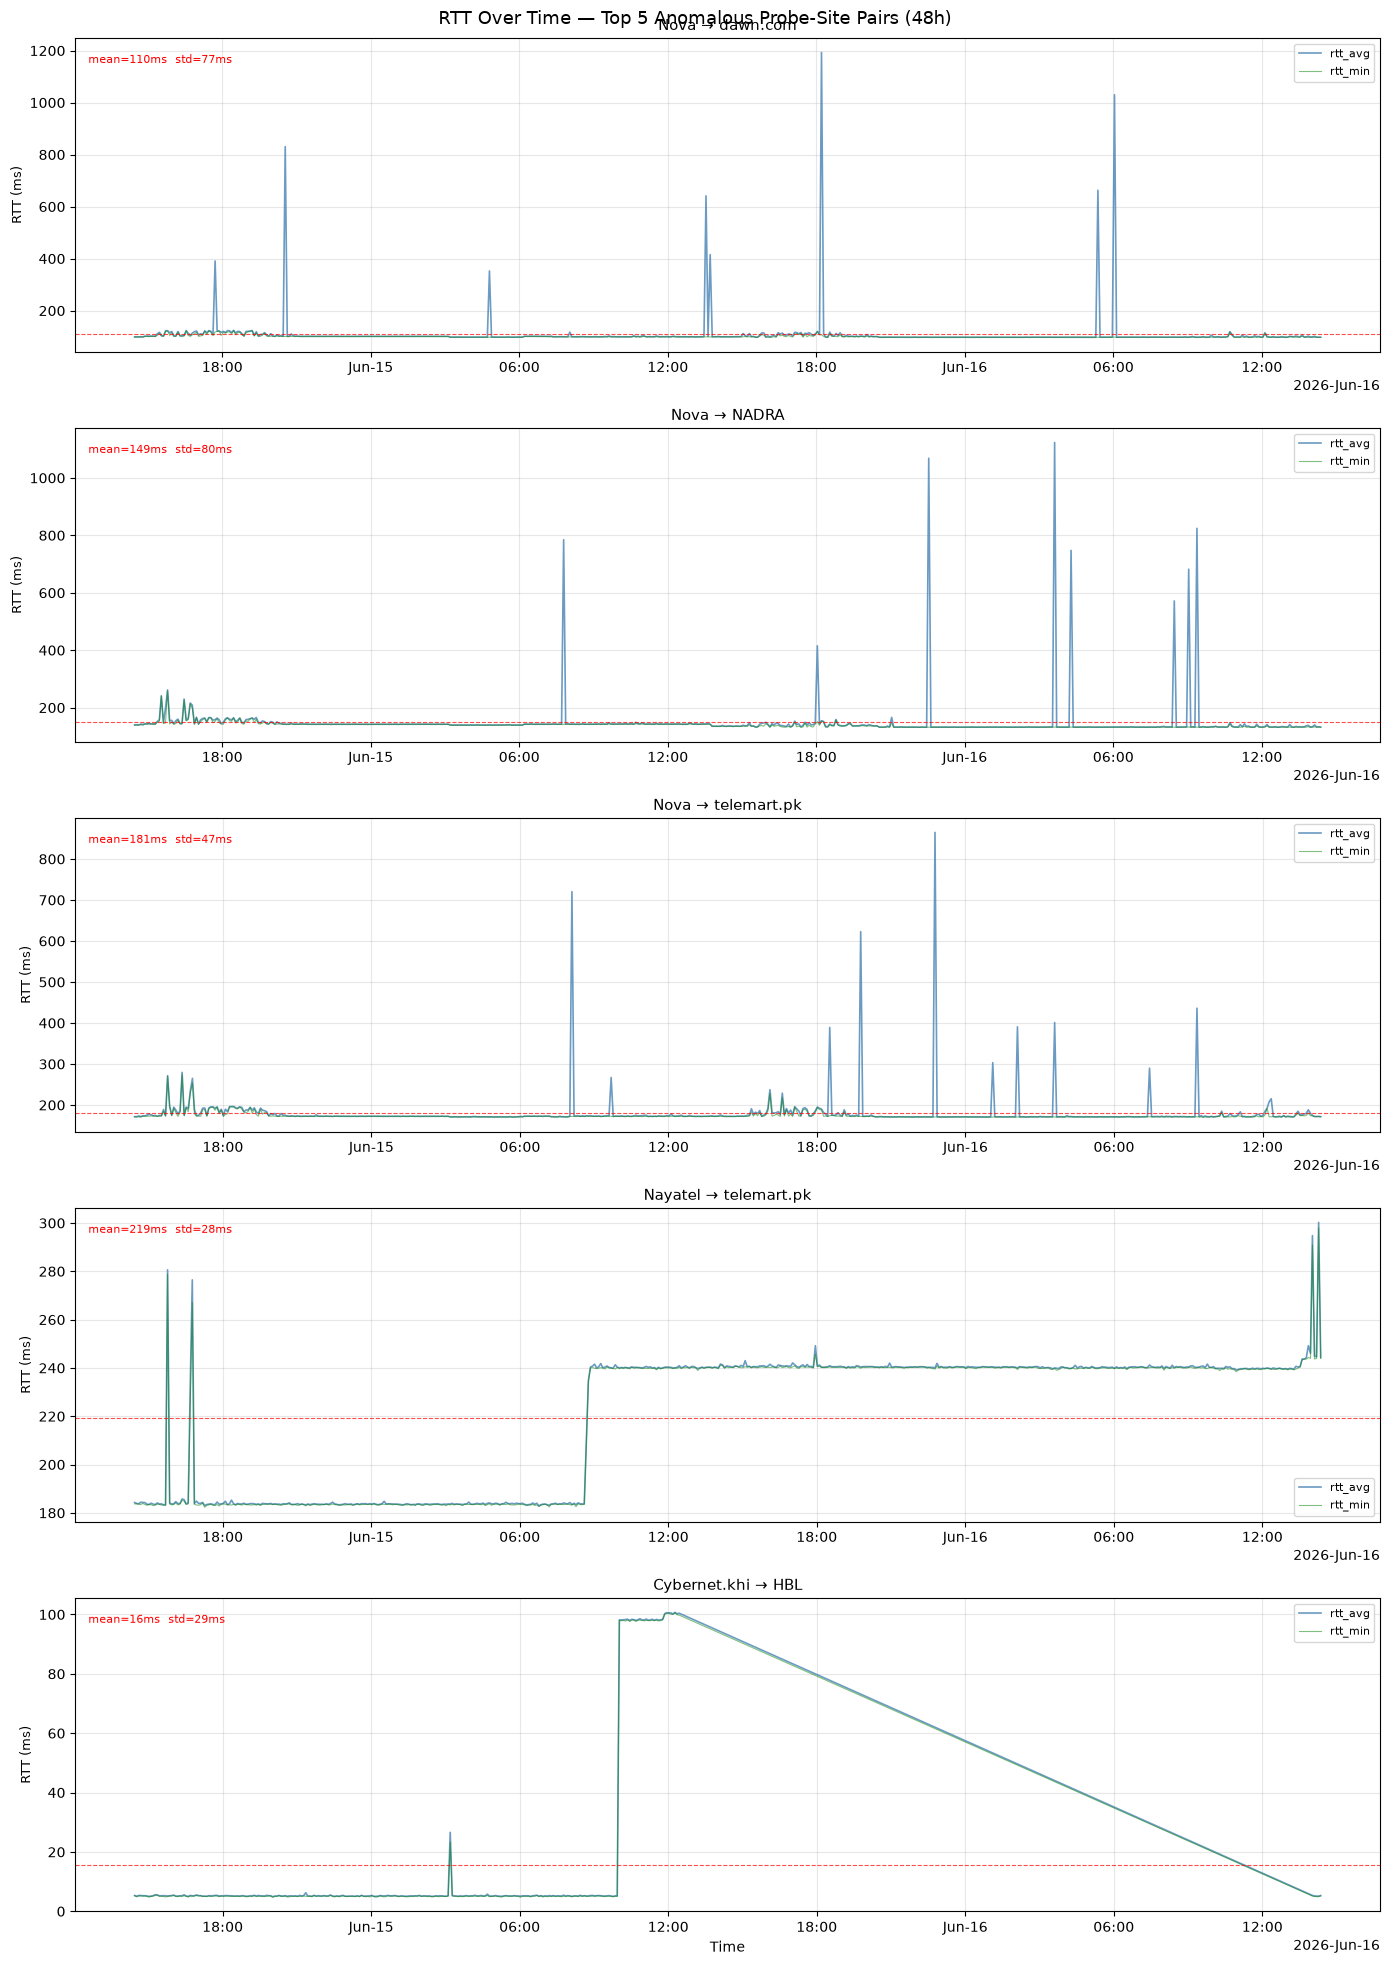

In [80]:
# ── Top 5 anomalous probe-site pairs — RTT over time ─────────────────────────

candidates = [
    (1015679, 'dawn.com',     'Nova → dawn.com'),
    (1015679, 'nadra.gov.pk', 'Nova → NADRA'),
    (1015679, 'telemart.pk',  'Nova → telemart.pk'),
    (60223,   'telemart.pk',  'Nayatel → telemart.pk'),
    (1016143, 'hbl.com',      'Cybernet.khi → HBL'),
]

fig, axes = plt.subplots(len(candidates), 1, figsize=(14, 4 * len(candidates)), sharex=False)

for ax, (probe_id, site_name, title) in zip(axes, candidates):

    # get site_id
    site_id = sites[sites['target_hostname'] == site_name].index[0]

    # filter pings
    mask = (pings_filtered['probe_id'] == probe_id) & (pings_filtered['site_id'] == site_id)
    data = pings_filtered[mask].copy()
    data['ping_time'] = pd.to_datetime(data['ping_time'])
    data = data.sort_values('ping_time')

    ax.plot(data['ping_time'], data['rtt_avg'],
            linewidth=1.2, color='steelblue', alpha=0.8, label='rtt_avg')
    ax.plot(data['ping_time'], data['rtt_min'],
            linewidth=0.8, color='green', alpha=0.5, label='rtt_min')

    ax.set_title(title, fontsize=11)
    ax.set_ylabel('RTT (ms)', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(
        mdates.AutoDateLocator()))

    # annotate mean and std
    mean_rtt = data['rtt_avg'].mean()
    std_rtt  = data['rtt_avg'].std()
    ax.axhline(mean_rtt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(0.01, 0.95, f'mean={mean_rtt:.0f}ms  std={std_rtt:.0f}ms',
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
            color='red')

axes[-1].set_xlabel('Time', fontsize=10)
plt.suptitle('RTT Over Time — Top 5 Anomalous Probe-Site Pairs (48h)', fontsize=13)
plt.tight_layout()
plt.show()